# Michaelis-Menten
***
## Setup the Environment
***

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from copy import deepcopy
sys.path.insert(1, os.path.abspath(os.path.join(os.getcwd(), '../')))

In [3]:
import gillespy3d_pp as gillespy2

In [4]:
gillespy2.__file__

'/Users/anisgolriz/Desktop/GillesPy3D/simulation_lib/gillespy3d_pp/__init__.py'

In [5]:
def create_michaelis_menten(sub0=301, enz0=120, rate1=0.0017, rate2=0.5, rate3=0.1, end_t=100):
    # Initialize Model
    model = gillespy2.Model(name="Michaelis_Menten")

    # Define Variables (GillesPy2.Species)
    A = gillespy2.Species(name='Substrate', initial_value=sub0)
    B = gillespy2.Species(name='Enzyme', initial_value=enz0)
    C = gillespy2.Species(name='Enzyme_Substrate_Complex', initial_value=0)
    D = gillespy2.Species(name='Product', initial_value=0)

    # Add Variables to Model
    model.add_species([A, B, C, D])

    # Define Parameters
    p1 = gillespy2.Parameter(name='rate1', expression=rate1)
    p2 = gillespy2.Parameter(name='rate2', expression=rate2)
    p3 = gillespy2.Parameter(name='rate3', expression=rate3)

    # Add Parameters to Model
    model.add_parameter([p1, p2, p3])

    # Define Reactions
    r1 = gillespy2.Reaction(
        name="r1", reactants={'Substrate': 1, 'Enzyme': 1},
        products={'Enzyme_Substrate_Complex': 1}, rate='rate1'
    )
    r2 = gillespy2.Reaction(
        name="r2", reactants={'Enzyme_Substrate_Complex': 1},
        products={'Substrate': 1, 'Enzyme': 1}, rate='rate2'
    )
    r3 = gillespy2.Reaction(
        name="r3", reactants={'Enzyme_Substrate_Complex': 1},
        products={'Enzyme': 1, 'Product': 1}, rate='rate3'
    )
    # Add Reactions to Model
    model.add_reaction([r1, r2, r3])

    # Define Timespan
    tspan = gillespy2.TimeSpan.linspace(end_t=end_t, num_points=int(end_t) + 1)

    # Set Model Timespan
    model.timespan(tspan)
    return model

### Instantiate the Model

### Parameters with Avogadro

In [26]:
# --- WITH Avogadro's number ---
nA  = 6.023e23     # Avogadro's number
vol = 1e-14        # system volume (L)

sub_conc, enz_conc = 5e-7, 2e-7     # molar (paper concentrations)
k1, k2, k3 = 1e6, .5, 0.1         # deterministic rate constants

sub0  = round(sub_conc * nA * vol)  # 301
enz0  = round(enz_conc * nA * vol)  # 120
rate1 = k1 / (nA * vol)             # ~0.00166
rate2 = k2
rate3 = k3
end_t = 100

model = create_michaelis_menten(sub0, enz0, rate1, rate2, rate3, end_t)

### Parameters without Avogadro

In [6]:
# --- WITHOUT Avogadro's number ---
sub0, enz0 = 301, 120
rate1, rate2, rate3 = 0.0017, 0.5, 0.1
end_t = 100

model = create_michaelis_menten(sub0, enz0, rate1, rate2, rate3, end_t)

In [19]:
dir(gillespy2)

['Ensemble',
 'Model',
 'NumPySSASolver',
 'Parameter',
 'Reaction',
 'Result',
 'Simulation',
 'Species',
 'TimeSpan',
 '__author__',
 '__builtins__',
 '__cached__',
 '__copyright__',
 '__description__',
 '__doc__',
 '__email__',
 '__file__',
 '__license__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__title__',
 '__url__',
 '__version__',
 'build_ensemble',
 'core',
 'error',
 'log',
 'logging',
 'model',
 'ode_solver',
 'parameter',
 'reaction',
 'result',
 'simulation',
 'solvers',
 'species',
 'sys',
 'tau_leaping_solver',
 'timespan',
 'utils',
 'version']

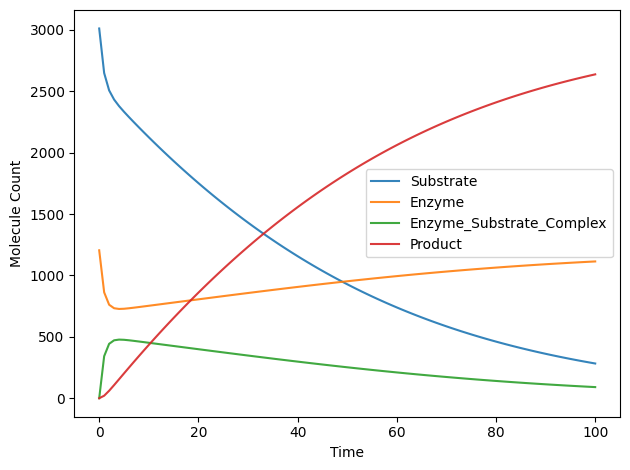

In [27]:
result = model.run(end_t=end_t, number_of_trajectories=1, dt=1)
result.plot()

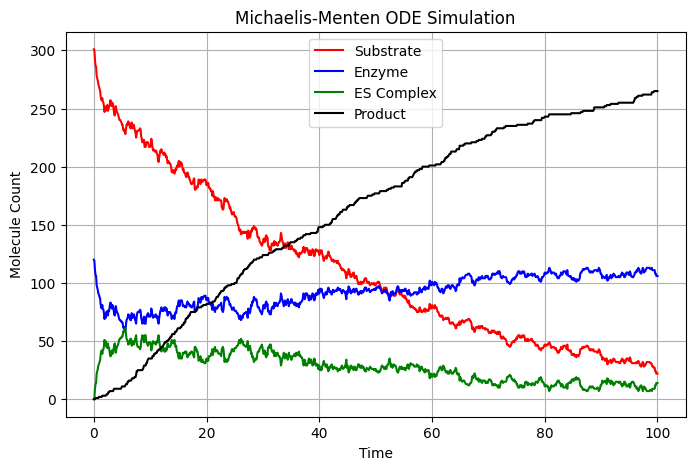

In [9]:
import matplotlib.pyplot as plt

sim = gillespy2.Simulation(model, "ODE", dt=0.1, end_t=end_t)
sim.reset()

times = []
substrate = []
enzyme = []
complex_ = []
product = []

prev_t = -1
while sim.get_time() < sim.end_t:
    t = sim.get_time()
    if t == prev_t:
        raise RuntimeError("Time is not advancing")
    prev_t = t
    times.append(sim.get_time())
    substrate.append(sim.get_species('Substrate'))
    enzyme.append(sim.get_species('Enzyme'))
    complex_.append(sim.get_species('Enzyme_Substrate_Complex'))
    product.append(sim.get_species('Product'))
    sim.run_until(sim.get_time() + sim.dt)

plt.figure(figsize=(8, 5))
plt.plot(times, substrate, label='Substrate', color='red')
plt.plot(times, enzyme, label='Enzyme', color='blue')
plt.plot(times, complex_, label='ES Complex', color='green')
plt.plot(times, product, label='Product', color='black')

plt.xlabel('Time')
plt.ylabel('Molecule Count')
plt.title('Michaelis-Menten ODE Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Step-through printout
sim = gillespy2.Simulation(model, "ODE", dt=0.1, end_t=10)

sim.reset()
while sim.get_time() < sim.end_t:
    print('t:', sim.get_time(), ' Substrate:', sim.get_species('Substrate'))
    sim.run_until(sim.get_time() + sim.dt)

t: 0  Substrate: 301
t: 0.1  Substrate: 295.0
t: 0.2  Substrate: 293.0
t: 0.30000000000000004  Substrate: 284.0
t: 0.4  Substrate: 282.0
t: 0.5  Substrate: 275.0
t: 0.6  Substrate: 272.0
t: 0.7  Substrate: 267.0
t: 0.7999999999999999  Substrate: 266.0
t: 0.8999999999999999  Substrate: 264.0
t: 0.9999999999999999  Substrate: 260.0
t: 1.0999999999999999  Substrate: 260.0
t: 1.2  Substrate: 262.0
t: 1.3  Substrate: 260.0
t: 1.4000000000000001  Substrate: 256.0
t: 1.5000000000000002  Substrate: 252.0
t: 1.6000000000000003  Substrate: 251.0
t: 1.7000000000000004  Substrate: 246.0
t: 1.8000000000000005  Substrate: 243.0
t: 1.9000000000000006  Substrate: 241.0
t: 2.0000000000000004  Substrate: 242.0
t: 2.1000000000000005  Substrate: 240.0
t: 2.2000000000000006  Substrate: 238.0
t: 2.3000000000000007  Substrate: 236.0
t: 2.400000000000001  Substrate: 235.0
t: 2.500000000000001  Substrate: 235.0
t: 2.600000000000001  Substrate: 236.0
t: 2.700000000000001  Substrate: 239.0
t: 2.800000000000001  

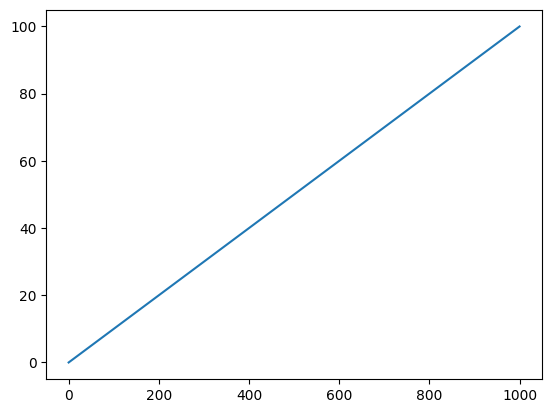

In [11]:
plt.plot(times)

In [12]:
substrate[-1]

np.float64(33.0)